# Diet and Gut Microbiome Richness: A COMBO Dataset Analysis

This project examines whether diet (fat and calorie intake) relates to gut microbiome richness (the number of distinct bacterial genera present) using a subset of the COMBO study done by Wu et al. (Details can be found on the README file). The dataset profiled 96 individuals' gut bacteria alongside their dietary intake. 

#### Approach: 
Load and merge raw data files, compute a richness metric per person, then use permutation testing to check whether above or below average fat and calorie intake are associated with differences in richness. 


In [1]:
import pandas as pd
import numpy as np

In [2]:
def otu_label(column):
    return[ f' OTU_{i+1}' for i in range(87)]

In [3]:
def person_label(column):
    return[ f' person {i+1}' for i in range(96)]

In [4]:
calorie_df = pd.read_csv('data/CaloriData.csv', header= None, names= ['calorie'])
calorie_df= (calorie_df.assign(person= person_label(calorie_df))
         .set_index('person') 
        ) #apply runs once per row and hence not appropriate here
calorie_df

,calorie
person,
person 1,0.467310
person 2,-0.533930
person 3,-1.744600
person 4,-0.795150
person 5,-0.032435
...,...
person 92,0.595100
person 93,0.757940
person 94,-0.199030


In [5]:
fat_df = pd.read_csv('data/FatData.csv', header=None, names=['fat'])
fat_df= (fat_df.assign(person= person_label(fat_df))
         .set_index('person') 
        )
fat_df

,fat
person,
person 1,-0.39394
person 2,-0.89720
person 3,-0.78355
person 4,-0.13302
person 5,0.16350
...,...
person 92,-1.02300
person 93,-0.23830
person 94,0.20399


In [6]:
diet_df = fat_df.merge(calorie_df, left_index= True, right_index= True)
diet_df 

,fat,calorie
person,,
person 1,-0.39394,0.467310
person 2,-0.89720,-0.533930
person 3,-0.78355,-1.744600
person 4,-0.13302,-0.795150
person 5,0.16350,-0.032435
...,...,...
person 92,-1.02300,0.595100
person 93,-0.23830,0.757940
person 94,0.20399,-0.199030


## To Note!
Fat and Calorie values in the original dataset were obtained by subtracting the values from the mean, hence resulting in small and sometimes even negative values in the data used in this project. These values can be better evaluated as the amount above or below the mean/average (a property we will be using later). 

In [7]:
names_phylo = ['otu_id', 'domain', 'phylum', 'class', 'order', 'family', 'genus'] 
bactphylo_df=  pd.read_csv("data/GeneraPhylo.csv", header= None, names=names_phylo).set_index('otu_id')
bactphylo_df

,domain,phylum,class,order,family,genus
otu_id,,,,,,
OTU_1,Bacteria,Actinobacteria,Actinobacteria,Coriobacteriales,Coriobacteriaceae,Asaccharobacter
OTU_2,Bacteria,Actinobacteria,Actinobacteria,Coriobacteriales,Coriobacteriaceae,Atopobium
OTU_3,Bacteria,Actinobacteria,Actinobacteria,Coriobacteriales,Coriobacteriaceae,Collinsella
OTU_4,Bacteria,Actinobacteria,Actinobacteria,Coriobacteriales,Coriobacteriaceae,Eggerthella
OTU_5,Bacteria,Actinobacteria,Actinobacteria,Coriobacteriales,Coriobacteriaceae,Gordonibacter
...,...,...,...,...,...,...
OTU_83,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas
OTU_84,Bacteria,Proteobacteria,Gammaproteobacteria,Xanthomonadales,Xanthomonadaceae,Stenotrophomonas
OTU_85,Bacteria,Synergistetes,Synergistia,Synergistales,Synergistaceae,Cloacibacillus


In [8]:
bact_df=  pd.read_csv("data/GeneraCounts.csv", header= None).T
bact_df= bact_df.assign(person = person_label(bact_df)).set_index('person')
bact_df

,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
person,,,,,,,,,,,,,,,,,,,,,
person 1,0,0,0,0,0,0,0,2878,0,69,...,0,0,0,0,0,0,0,0,0,0
person 2,0,0,0,0,0,0,0,578,180,0,...,2,0,0,1,0,0,0,0,0,0
person 3,0,0,0,0,0,0,0,3503,143,0,...,0,0,0,0,0,0,0,0,0,0
person 4,0,0,0,0,0,0,0,2162,1,0,...,3,0,0,0,0,0,0,0,0,0
person 5,0,0,0,2,0,0,0,4453,0,0,...,9,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
person 92,0,0,0,0,0,0,0,1349,0,0,...,0,2,0,0,0,0,0,0,0,0
person 93,0,0,0,4,0,0,0,4154,0,9,...,0,0,0,0,0,0,0,0,0,0
person 94,0,0,0,0,0,0,0,2342,731,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# which bacteria is the most common in the test population?
common= (bact_df>0).sum(axis=0)
common_bact= ( pd.DataFrame().assign(otu_id= otu_label(common), occurence= common)
              .set_index('otu_id').sort_values(by= 'occurence', ascending=False)
             )
common_bact

,occurence
otu_id,
OTU_45,96
OTU_37,96
OTU_8,96
OTU_53,94
OTU_12,92
...,...
OTU_17,1
OTU_75,1
OTU_73,1


#### Checkpoint:
The most commonly occurring bacteria in this data set are OTU 45, OTU 37, and OTU 8 with all three present in all the 96 test subjects. 

In [10]:
bactphylo_df.take([44, 36, 7]) # zooming in on the respective bacterias

,domain,phylum,class,order,family,genus
otu_id,,,,,,
OTU_45,Bacteria,Firmicutes,Clostridia,Clostridiales,Lachnospiraceae,Roseburia
OTU_37,Bacteria,Firmicutes,Clostridia,Clostridiales,Incertae_Sedis_XIV,Blautia
OTU_8,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides


In [31]:
# calculating the count of distinct types of bacteria for each person

richness= (bact_df>0).sum(axis=1) # axis=1 collapses all columns in a row into one result per row
richness

person
person 1     27
person 2     23
person 3     26
person 4     26
person 5     22
             ..
person 92    28
person 93    26
person 94    22
person 95    28
person 96    26
Length: 96, dtype: int64

In [32]:
merged_final= (
    diet_df.assign(microbiome_richness= richness)

)
merged_final

,fat,calorie,microbiome_richness
person,,,
person 1,-0.39394,0.467310,27
person 2,-0.89720,-0.533930,23
person 3,-0.78355,-1.744600,26
person 4,-0.13302,-0.795150,26
person 5,0.16350,-0.032435,22
...,...,...,...
person 92,-1.02300,0.595100,28
person 93,-0.23830,0.757940,26
person 94,0.20399,-0.199030,22


In [39]:
# Data quality check to verify there are no missing values across the merged dataset. 

print('Missing values check:')
print( diet_df.isna().sum().sum())
print(bact_df.isna().sum().sum())

 # double sum because I want to know the number of missing values across the table rather than column-wise

Missing values check:
0
0


## Fat intake and Gut bacteria patterns

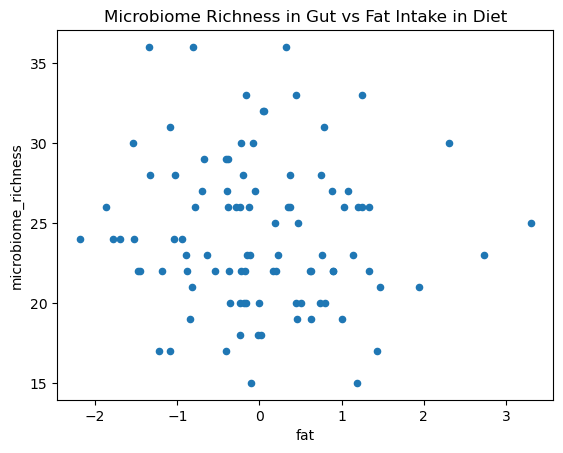

In [14]:
scatter_fat= (
    merged_final.plot(kind= 'scatter', x='fat',y= 'microbiome_richness',
                   title= 'Microbiome Richness in Gut vs Fat Intake in Diet')
)

#### Understanding the graph:

The points are scattered in dense, formless cloud pattern across the range of fat intake. Based on the pattern, it can be seen that fat intake does not appear to meaningfully predict microbiome richness in this dataset. We will perform a statistical test to further understand this. 

## Running Permutation test
Null hypothesis: Fat intake has NO effect on microbiome richness. Any difference observed is due to random chance. 

Alternative hypothesis: Fat intake does have an effect on microbiome richness. 

In [15]:
def intake(value):
        if value> 0:
            return('above average')

        else:
            return('below average')

  

In [16]:
col_sort= merged_final.get('fat').apply(intake)
fat_df_split= (
    merged_final.assign(fat_group= col_sort)
    .get(['microbiome_richness', 'fat_group'])
)
fat_df_split

,microbiome_richness,fat_group
person,,
person 1,27,below average
person 2,23,below average
person 3,26,below average
person 4,26,below average
person 5,22,above average
...,...,...
person 92,28,below average
person 93,26,below average
person 94,22,above average


Reasoning for splitting into groups: Since we wish to understand whether the amount of fat intake has an effect on the richness
of gut bacteria found in a person, we can assign labels according to the fat intake value for each test subject and then carry a permutation test by shuffling the labels and calculating the test statistic to understand if the difference (if any) is due to random chance or if there is a relation

In [34]:
observed_f= fat_df_split.groupby('fat_group').median()
observed_f # used median as a measure of central tendency as both data groups have same max and min however the data is differently skewed


,microbiome_richness
fat_group,
above average,23.0
below average,24.0


In [18]:
observed_diff_f= np.abs(observed_f.get('microbiome_richness').iloc[1]- observed_f.get('microbiome_richness').iloc[0])
observed_diff_f

1.0

In [19]:
def diff(df):
    medians= df.get(['shuffle', 'microbiome_richness']).groupby('shuffle').median()
    return np.abs((medians.get('microbiome_richness').loc['below average'])- medians.get('microbiome_richness').loc['above average'])

In [30]:
rep = 5000
stat= np.array([ ])

for i in np.arange(rep):
    shuffled = fat_df_split.assign(shuffle= np.random.permutation(fat_df_split.get('fat_group')))
    
    test_stat= diff(shuffled)
    stat= np.append(stat, test_stat)

# null/ permutation distribution
left=  np.percentile(stat, 2.5)
right= np.percentile(stat, 97.5)
print(left,right)

1.0 4.0


In [22]:
p_value= np.mean(stat>= observed_diff_f)
print(f'p-value: {p_value}, observed difference: {observed_diff_f}')

p-value: 1.0, observed difference: 1.0


#### Checkpoint:
The p-value of 1.0 (a value far greater than the cutoff of 0.05) indicates that we do not have sufficient statistical evidence to reject the null hypothesis. This also confirms our findings in the graph. Hence, it can be said that fat intake has no effect on microbiome richness in the gut. 

## Calorie intake and Gut bacteria patterns 

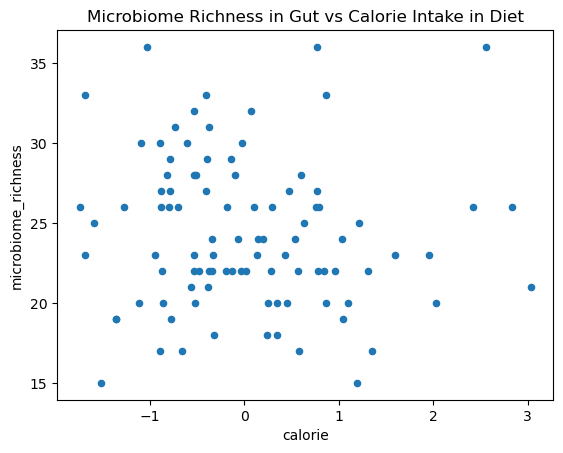

In [23]:
# a scatter plot to get a rough understanding of data patterns

scatter_cal= (
    merged_final.plot(kind= 'scatter', x='calorie',y= 'microbiome_richness',
                   title= 'Microbiome Richness in Gut vs Calorie Intake in Diet')
)

In [24]:
# repeating the same process with calorie data

calo_sort= merged_final.get('calorie').apply(intake)
cal_df_split= (
    merged_final.assign(calorie_group= calo_sort)
    .get(['microbiome_richness', 'calorie_group'])
)
cal_df_split

,microbiome_richness,calorie_group
person,,
person 1,27,above average
person 2,23,below average
person 3,26,below average
person 4,26,below average
person 5,22,below average
...,...,...
person 92,28,above average
person 93,26,above average
person 94,22,below average


In [25]:
observed_c= cal_df_split.groupby('calorie_group').median()
observed_c

,microbiome_richness
calorie_group,
above average,23.0
below average,25.0


In [26]:
observed_diff_c= np.abs(observed_c.get('microbiome_richness').iloc[1]-observed_c.get('microbiome_richness').iloc[0])
observed_diff_c

2.0

In [29]:
rep = 5000
stat_cal= np.array([ ])

for i in np.arange(rep):
    shuffled = cal_df_split.assign(shuffle= np.random.permutation(cal_df_split.get('calorie_group')))
    
    test_stat_cal= diff(shuffled)
    stat_cal= np.append(stat_cal, test_stat_cal)

# null/ permutation distribution
left=  np.percentile(stat_cal, 2.5)
right= np.percentile(stat_cal, 97.5)
print(left,right)

1.0 4.0


In [28]:
p_value_c= np.mean(stat_cal>= observed_diff_c)
print(f'p-value: {p_value_c}, observed difference: {observed_diff_c}')

p-value: 0.2568, observed difference: 2.0


## Checkpoint:

the p-value obtained here is greater than our cutoff of 0.05 indicates that the result is statistically not significant and that we fail to reject the null hypothesis. Further, the number 0.2568 shows that roughly 1 out 4 random shuffles produced a test statistic value that was a least equal to or greater than the observed statistic of 2.0. 

# Wrap-up:

This project asked a simple question: does what we eat shape the bacteria living in our gut? Using a subset from the dataset (Wu et al., 2011), I compared fat and calorie intake against bacterial richness in 96 people. 

### Limitations:
This analysis has two notable limitations: the small sample size (n=96) 
limits statistical power, meaning a real effect could exist but be too 
subtle to detect at this scale. Additionally, fat and calorie values 
were mean-centered in the raw data, so comparisons reflect relative 
standing against the group average rather than absolute intake amounts.

### Conclusion
With that in mind, neither comparison reached statistical significance (fat: p = 1.0; 
calorie: p = 0.26), so I can't claim a real relationship here and I 
think that's worth saying plainly rather than stretching the data to 
find one. Calorie intake's difference was somewhat less consistent with 
pure chance than fat's, which might be worth a closer look with a 
larger sample.

More than a specific finding, this project was my attempt to actually 
sit with real, messy biological data the way a researcher would. That meant
tracing down the right files, fixing my own bugs, and learning to trust 
a statistical test's answer even when it isn't the exciting one.